# Blood-Brain Barrier Permeability Prediction

Predict whether small molecules are likely to cross the blood-brain barrier (BBB) from molecular structure.

## Objective

Build an interpretable molecular classification pipeline and evaluate whether it generalizes to structurally distinct compounds using a scaffold-based train/test split.

## Pipeline

1. Load the MoleculeNet BBBP benchmark
2. Generate ECFP4 (Morgan) fingerprints
3. Split by Bemis-Murcko scaffold
4. Benchmark logistic regression and random forest models
5. Add RDKit physicochemical descriptors and train LightGBM
6. Evaluate with ROC-AUC, PR-AUC, and threshold-based classification metrics
7. Inspect important descriptors and Morgan substructures
8. Provide a small molecule-screening utility

> **Key result:** the hybrid LightGBM model reaches 0.901 ROC-AUC and 0.971 PR-AUC on the held-out scaffold test set in this notebook.

## Important caveat

The reported test metrics come from one fixed scaffold split. They are useful for demonstrating the modeling workflow, but should not be treated as a precise estimate of out-of-sample performance across all chemical space.


## 1. Dataset and target

The benchmark contains molecular SMILES strings with a binary BBB permeability label. Missing SMILES or labels are removed before molecular featurization.


In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem, Descriptors

# Keep the notebook readable while still reporting how many structures fail RDKit parsing.
RDLogger.DisableLog("rdApp.*")
warnings.filterwarnings("ignore")

URL = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/BBBP.csv"
df = pd.read_csv(URL).dropna(subset=["smiles", "p_np"]).rename(
    columns={"smiles": "Drug", "p_np": "Y"}
)

print(f"Rows after missing-value filtering: {len(df):,}")
print(f"Penetrant (1): {(df['Y'] == 1).sum():,}")
print(f"Non-penetrant (0): {(df['Y'] == 0).sum():,}")
df[["name", "Drug", "Y"]].head()


Rows after missing-value filtering: 2,050
Penetrant (1): 1,567
Non-penetrant (0): 483


,name,Drug,Y
0,Propanolol,[Cl].CC(C)NCC(O)COc1cccc2ccccc12,1
1,Terbutylchlorambucil,C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl,1
2,40730,c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO...,1
3,24,C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C,1
4,cloxacillin,Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)...,1


## 2. Molecular representation

Each valid SMILES is converted to a 1,024-bit ECFP4/Morgan fingerprint (radius = 2). Molecules that cannot be parsed by RDKit are removed from the modeling set.


In [2]:
def smiles_to_ecfp(smiles_series, radius=2, n_bits=1024):
    """Convert SMILES strings to binary Morgan fingerprints."""
    fingerprints = []
    valid_indices = []

    for idx, smiles in enumerate(smiles_series):
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            continue
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
        fingerprints.append(np.asarray(fp, dtype=np.uint8))
        valid_indices.append(idx)

    return np.asarray(fingerprints), valid_indices

X, valid_idx = smiles_to_ecfp(df["Drug"])
model_df = df.iloc[valid_idx].reset_index(drop=True)
y = model_df["Y"].to_numpy()
valid_smiles = model_df["Drug"].tolist()

print(f"Valid RDKit molecules: {len(model_df):,}")
print(f"Removed during RDKit parsing: {len(df) - len(model_df):,}")
print(f"Fingerprint matrix: {X.shape}")


Valid RDKit molecules: 2,039
Removed during RDKit parsing: 11
Fingerprint matrix: (2039, 1024)


## 3. Scaffold-based train/test split

Randomly splitting individual molecules can place closely related compounds in both train and test sets. To make the evaluation more chemically demanding, all molecules sharing a Bemis-Murcko scaffold are kept in the same split.


In [11]:
from collections import defaultdict
from rdkit.Chem.Scaffolds import MurckoScaffold
import random

def generate_scaffold(smiles, include_chirality=False):
    """Return the Bemis-Murcko scaffold for a molecule."""
    mol = Chem.MolFromSmiles(smiles)
    return MurckoScaffold.MurckoScaffoldSmiles(
        mol=mol, includeChirality=include_chirality
    )

scaffold_to_indices = defaultdict(list)
for idx, smiles in enumerate(valid_smiles):
    scaffold_to_indices[generate_scaffold(smiles)].append(idx)

# Fixed seed makes the split reproducible. Scaffold clusters are never split across train/test.
random.seed(42)
clusters = list(scaffold_to_indices.values())
random.shuffle(clusters)

train_indices, test_indices = [], []
cutoff = int(0.80 * len(valid_smiles))
for cluster in clusters:
    if len(train_indices) + len(cluster) <= cutoff:
        train_indices.extend(cluster)
    else:
        test_indices.extend(cluster)

X_train, X_test = X[train_indices], X[test_indices]
y_train, y_test = y[train_indices], y[test_indices]

train_scaffolds = {generate_scaffold(valid_smiles[i]) for i in train_indices}
test_scaffolds = {generate_scaffold(valid_smiles[i]) for i in test_indices}

print(f"Train set: {len(X_train):,} molecules ({len(X_train)/len(valid_smiles):.1%})")
print(f"Test set:  {len(X_test):,} molecules ({len(X_test)/len(valid_smiles):.1%})")
print(f"Unique train scaffolds: {len(train_scaffolds):,}")
print(f"Unique test scaffolds:  {len(test_scaffolds):,}")
print(f"Scaffold overlap: {len(train_scaffolds & test_scaffolds)}")


Train set: 1,631 molecules (80.0%)
Test set:  408 molecules (20.0%)
Unique train scaffolds: 799
Unique test scaffolds:  226
Scaffold overlap: 0


## 4. Fingerprint-only baselines

Logistic regression provides a simple linear baseline; random forest tests whether nonlinear interactions among fingerprint bits improve performance.


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

models = {}
results = []

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_probs = lr.predict_proba(X_test)[:, 1]
results.append({
    "Model": "Logistic Regression",
    "Features": "ECFP4",
    "ROC-AUC": roc_auc_score(y_test, lr_probs),
    "PR-AUC": average_precision_score(y_test, lr_probs),
})
models["Logistic Regression"] = lr

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
rf_probs = rf.predict_proba(X_test)[:, 1]
results.append({
    "Model": "Random Forest",
    "Features": "ECFP4",
    "ROC-AUC": roc_auc_score(y_test, rf_probs),
    "PR-AUC": average_precision_score(y_test, rf_probs),
})
models["Random Forest"] = rf

results_df = pd.DataFrame(results)
results_df.style.format({"ROC-AUC": "{:.3f}", "PR-AUC": "{:.3f}"})


,Model,Features,ROC-AUC,PR-AUC
0,Logistic Regression,ECFP4,0.835,0.940
1,Random Forest,ECFP4,0.889,0.963


## 5. Hybrid molecular features and LightGBM

The final feature set combines the structural fingerprints with standard RDKit 2D descriptors. Descriptor scaling is fit on the training set only.


In [13]:
from rdkit.ML.Descriptors import MoleculeDescriptors
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb

descriptor_names = [name for name, _ in Descriptors.descList]
calculator = MoleculeDescriptors.MolecularDescriptorCalculator(descriptor_names)
valid_mols = [Chem.MolFromSmiles(smiles) for smiles in valid_smiles]
desc_features = np.asarray([calculator.CalcDescriptors(mol) for mol in valid_mols], dtype=float)
desc_features = np.nan_to_num(desc_features, nan=0.0, posinf=0.0, neginf=0.0)

scaler = StandardScaler()
desc_train = scaler.fit_transform(desc_features[train_indices])
desc_test = scaler.transform(desc_features[test_indices])

X_train_combined = np.hstack([X_train, desc_train])
X_test_combined = np.hstack([X_test, desc_test])

scale_pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)

lgb_clf = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbosity=-1,
)
lgb_clf.fit(X_train_combined, y_train)
lgb_probs = lgb_clf.predict_proba(X_test_combined)[:, 1]

results_df = pd.concat([
    results_df,
    pd.DataFrame([{
        "Model": "LightGBM",
        "Features": "ECFP4 + RDKit descriptors",
        "ROC-AUC": roc_auc_score(y_test, lgb_probs),
        "PR-AUC": average_precision_score(y_test, lgb_probs),
    }])
], ignore_index=True)

print(f"Combined feature matrix: {X_train_combined.shape}")
results_df.style.format({"ROC-AUC": "{:.3f}", "PR-AUC": "{:.3f}"})


Combined feature matrix: (1631, 1234)


,Model,Features,ROC-AUC,PR-AUC
0,Logistic Regression,ECFP4,0.835,0.940
1,Random Forest,ECFP4,0.889,0.963
2,LightGBM,ECFP4 + RDKit descriptors,0.901,0.971


## 6. Test-set evaluation

ROC-AUC and PR-AUC evaluate ranking quality across thresholds. For a concrete operating point, the following classification report uses a 0.50 threshold **selected a priori for demonstration** rather than tuned on the test set.


Model comparison


,Model,Features,ROC-AUC,PR-AUC
0,Logistic Regression,ECFP4,0.835,0.940
1,Random Forest,ECFP4,0.889,0.963
2,LightGBM,ECFP4 + RDKit descriptors,0.901,0.971



LightGBM classification report (threshold = 0.50)
                   precision    recall  f1-score   support

Non-penetrant (0)       0.74      0.62      0.67        81
    Penetrant (1)       0.91      0.94      0.93       327

         accuracy                           0.88       408
        macro avg       0.82      0.78      0.80       408
     weighted avg       0.87      0.88      0.88       408



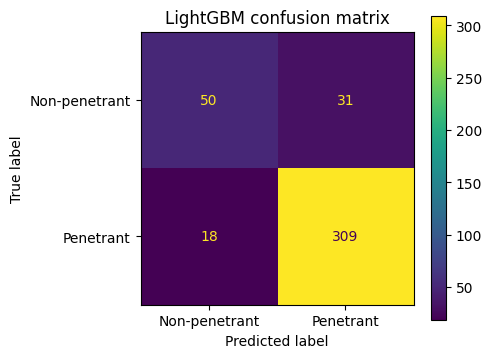

In [14]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

print("Model comparison")
display(results_df.style.format({"ROC-AUC": "{:.3f}", "PR-AUC": "{:.3f}"}))

threshold = 0.50
lgb_preds = (lgb_probs >= threshold).astype(int)
print()
print(f"LightGBM classification report (threshold = {threshold:.2f})")
print(classification_report(
    y_test, lgb_preds,
    target_names=["Non-penetrant (0)", "Penetrant (1)"],
    digits=2,
))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, lgb_preds,
    display_labels=["Non-penetrant", "Penetrant"],
    values_format="d",
    ax=ax,
)
ax.set_title("LightGBM confusion matrix")
plt.tight_layout()
plt.show()


## 7. Feature importance and molecular interpretation

LightGBM feature importance is used here for **model interpretation**, not as evidence of causal molecular effects. Morgan bits identify hashed local chemical environments; their association with the target should be interpreted cautiously.


Top 15 model features


,Feature,Importance
0,TPSA,179
1,qed,176
2,VSA_EState3,134
3,MinPartialCharge,127
4,BCUT2D_LOGPLOW,119
5,BalabanJ,104
6,MolLogP,102
7,VSA_EState8,89
8,VSA_EState5,87
9,BCUT2D_MWLOW,86


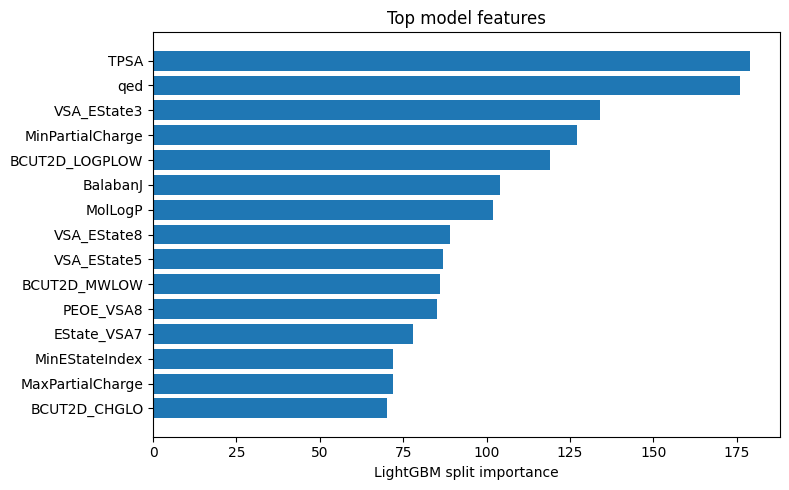

Top Morgan bits: [237, 540, 798, 1, 408]


In [15]:
feature_names = [f"Bit_{i}" for i in range(1024)] + descriptor_names
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": lgb_clf.feature_importances_,
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print("Top 15 model features")
display(importance_df.head(15))

fig, ax = plt.subplots(figsize=(8, 5))
top15 = importance_df.head(15).sort_values("Importance")
ax.barh(top15["Feature"], top15["Importance"])
ax.set_xlabel("LightGBM split importance")
ax.set_title("Top model features")
plt.tight_layout()
plt.show()

top_bits = [int(x.replace("Bit_", "")) for x in importance_df[importance_df["Feature"].str.startswith("Bit_")].head(5)["Feature"]]
print("Top Morgan bits:", top_bits)


In [18]:
from rdkit.Chem import Draw
from IPython.display import display

def visualize_morgan_bit(target_bit, smiles_list, radius=2, n_bits=1024):
    """Display one example chemical environment associated with a Morgan bit."""
    for smiles in smiles_list:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            continue
        bit_info = {}
        AllChem.GetMorganFingerprintAsBitVect(
            mol, radius=radius, nBits=n_bits, bitInfo=bit_info
        )
        if target_bit in bit_info:
            print(f"Example chemical environment for Morgan bit {target_bit}")
            display(Draw.DrawMorganBit(mol, target_bit, bit_info, useSVG=False))
            return mol, bit_info
    print(f"Morgan bit {target_bit} was not found in the supplied structures.")
    return None, None

def evaluate_bit_association(target_bit, smiles_list, labels, radius=2, n_bits=1024):
    """Compare observed target rates with and without a Morgan bit."""
    labels = np.asarray(labels)
    has_bit = []
    for smiles in smiles_list:
        mol = Chem.MolFromSmiles(smiles)
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
        has_bit.append(bool(fp[target_bit]))
    has_bit = np.asarray(has_bit)

    rate_with = labels[has_bit].mean()
    rate_without = labels[~has_bit].mean()
    return {
        "bit_id": target_bit,
        "count": int(has_bit.sum()),
        "rate_with": float(rate_with),
        "rate_without": float(rate_without),
        "delta": float(rate_with - rate_without),
    }

bit_results = pd.DataFrame([
    evaluate_bit_association(bit, valid_smiles, y) for bit in top_bits
]).sort_values("delta")

bit_results.style.format({
    "rate_with": "{:.1%}",
    "rate_without": "{:.1%}",
    "delta": "{:+.1%}",
})


,bit_id,count,rate_with,rate_without,delta
3,1,488,63.5%,80.6%,-17.1%
0,237,125,68.0%,77.1%,-9.1%
4,408,77,68.8%,76.8%,-8.0%
2,798,146,82.9%,76.0%,+6.9%
1,540,165,86.7%,75.6%,+11.1%


Example chemical environment for Morgan bit 237


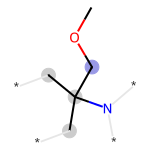

,bit_id,count,rate_with,rate_without,delta
0,237,125,0.68,0.770637,-0.090637


In [19]:
# Visualize the highest-ranked Morgan bit as one example, then inspect its observed association.
target_bit = top_bits[0]
visualize_morgan_bit(target_bit, valid_smiles)
display(bit_results.query("bit_id == @target_bit"))


## 8. Molecule screening utility

This utility applies the same fingerprinting and descriptor preprocessing used during training to a new SMILES string. The probability is a model estimate, not an experimental measurement.


In [20]:
def screen_molecule(smiles: str):
    """Return a compact BBB screening report for a new SMILES string."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Invalid SMILES string: {smiles}")

    fp = np.asarray(
        AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024),
        dtype=np.uint8,
    ).reshape(1, -1)
    desc = np.asarray([calculator.CalcDescriptors(mol)], dtype=float)
    desc = np.nan_to_num(desc, nan=0.0, posinf=0.0, neginf=0.0)
    x = np.hstack([fp, scaler.transform(desc)])
    probability = float(lgb_clf.predict_proba(x)[0, 1])

    return {
        "smiles": smiles,
        "bbb_probability": probability,
        "prediction": "Penetrant" if probability >= 0.5 else "Non-penetrant",
        "TPSA": Descriptors.TPSA(mol),
        "MolLogP": Descriptors.MolLogP(mol),
        "HBD": Descriptors.NumHDonors(mol),
        "top_morgan_bit_present": [int(bit) for bit in top_bits if fp[0, bit]],
    }

examples = [
    ("Example 1", "CN1C=NC2=C1C(=O)N(C(=O)N2C)C"),
    ("Example 2", "CC1(C(N2C(S1)C(C2=O)NC(=O)CC3=CC=CC=C3)C(=O)O)C"),
]
for label, smiles in examples:
    result = screen_molecule(smiles)
    print(f"{label}: {result['prediction']} ({result['bbb_probability']:.1%})")
    print(f"  TPSA={result['TPSA']:.1f}, MolLogP={result['MolLogP']:.2f}, HBD={result['HBD']}")
    print(f"  Top Morgan bits present: {result['top_morgan_bit_present']}")
    print()


Example 1: Penetrant (92.2%)
  TPSA=61.8, MolLogP=-1.03, HBD=0
  Top Morgan bits present: []

Example 2: Non-penetrant (1.9%)
  TPSA=86.7, MolLogP=0.86, HBD=2
  Top Morgan bits present: []



## 9. Limitations and next steps

- The dataset is relatively small and imbalanced toward BBB-penetrant molecules.
- Performance is reported on one fixed scaffold split; repeated scaffold cross-validation would provide a more robust estimate.
- Morgan fingerprint bits are hashed representations and are not causal explanations.
- Threshold-dependent metrics depend on the chosen operating threshold; threshold selection should be performed on validation data rather than the held-out test set.
- The screening utility should be treated as a prioritization aid, not a substitute for experimental permeability assays.

### Reproducibility

The split seed and model random seeds are fixed at 42. The notebook downloads the public BBBP CSV directly and can be rerun from top to bottom.
